In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using device: cuda
Number of classes: 37
Test samples: 3669

LOADING AND EVALUATING ALL FUSION MODELS

EVALUATING FEATURE MODEL
Loaded feature model from epoch 7
Best validation accuracy: 96.74%



--- FEATURE RESULTS ---
Test Accuracy:  94.66%
F1 Score:       0.9462
ROC AUC:        0.9990
Alpha Mean:     0.4700
Alpha Std:      0.0339
----------------------------------------

EVALUATING GATED MODEL
Loaded gated model from epoch 6
Best validation accuracy: 97.15%



--- GATED RESULTS ---
Test Accuracy:  94.88%
F1 Score:       0.9486
ROC AUC:        0.9987
Alpha Mean:     0.3832
Alpha Std:      0.0880
----------------------------------------

EVALUATING RESIDUAL MODEL
Loaded residual model from epoch 6
Best validation accuracy: 96.74%



--- RESIDUAL RESULTS ---
Test Accuracy:  95.07%
F1 Score:       0.9504
ROC AUC:        0.9991
Alpha Mean:     0.4605
Alpha Std:      0.0423
----------------------------------------

EVALUATING ADAPTIVE MODEL
Loaded adaptive model from epoch 5
Best validation accuracy: 96.88%



--- ADAPTIVE RESULTS ---
Test Accuracy:  95.26%
F1 Score:       0.9522
ROC AUC:        0.9987
Alpha Mean:     0.4496
Alpha Std:      0.0519
----------------------------------------

COMPARISON SUMMARY
  Method  Validation  Test Accuracy  F1 Score  Global Path  Part Path  Alpha Mean  Alpha Std
 Feature       96.74          94.66    0.9462        94.41      94.55      0.4700     0.0339
   Gated       97.15          94.88    0.9486        94.63      94.44      0.3832     0.0880
Residual       96.74          95.07    0.9504        95.01      94.90      0.4605     0.0423
Adaptive       96.88          95.26    0.9522        94.96      94.93      0.4496     0.0519

GENERATING COMPARISON PLOTS


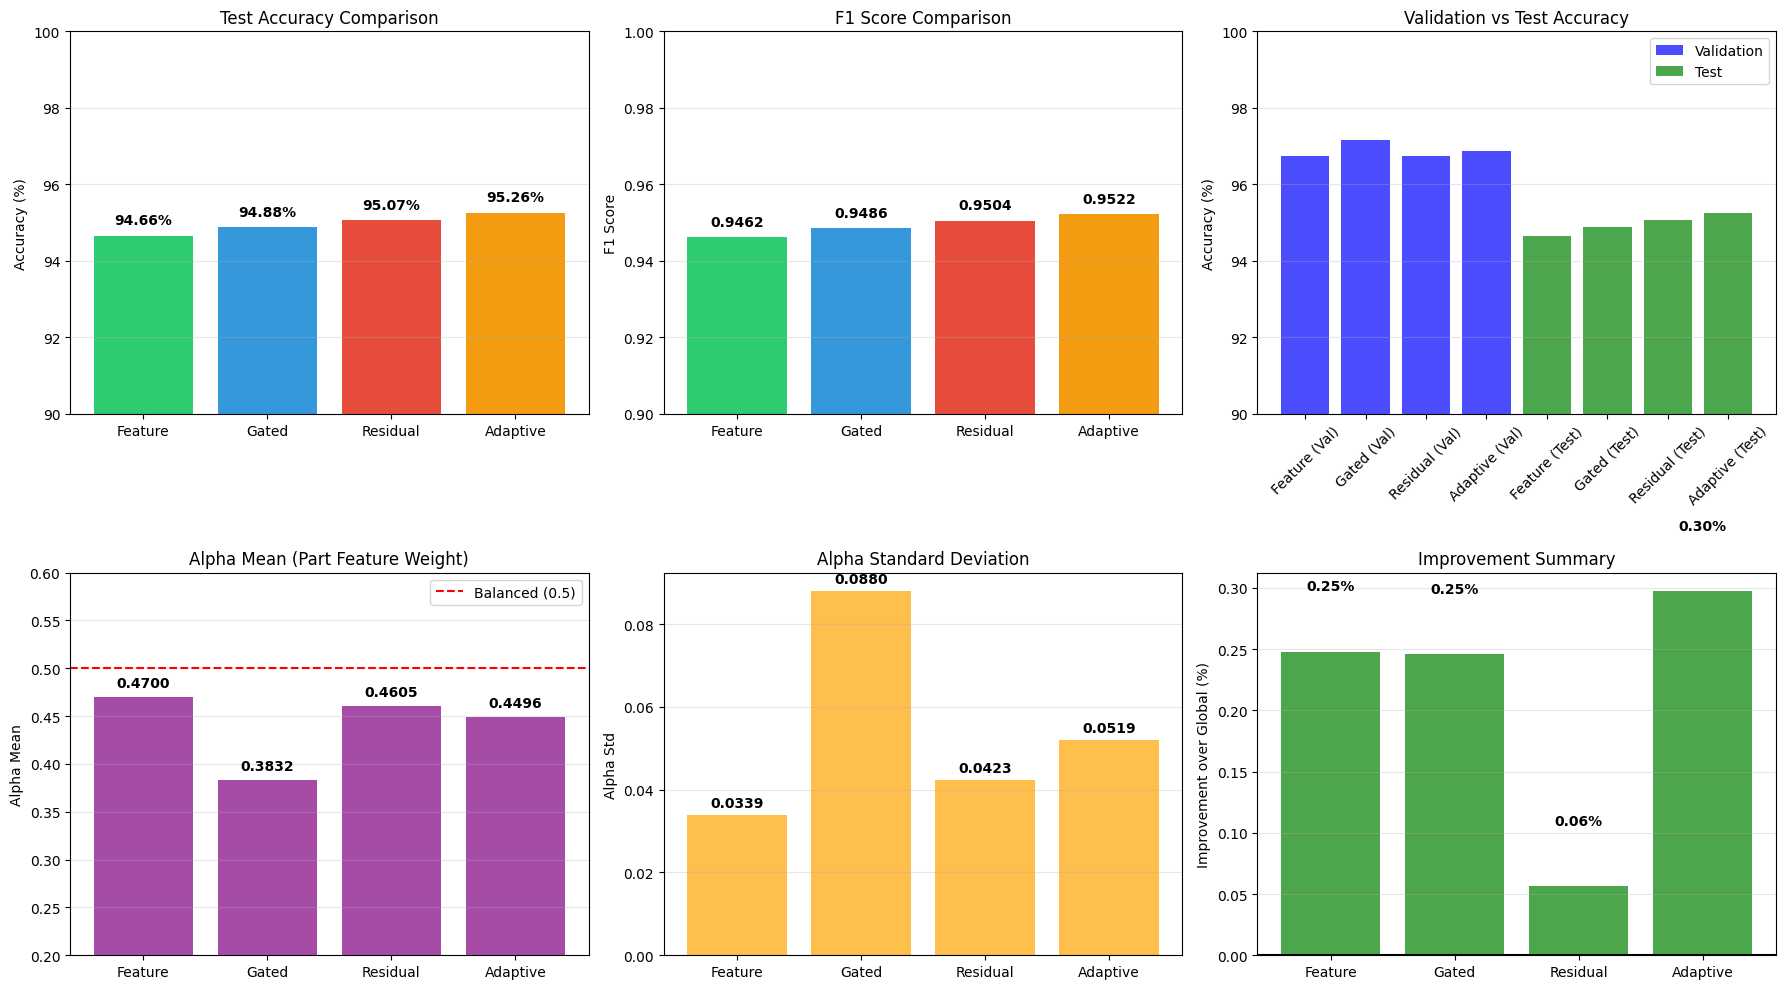

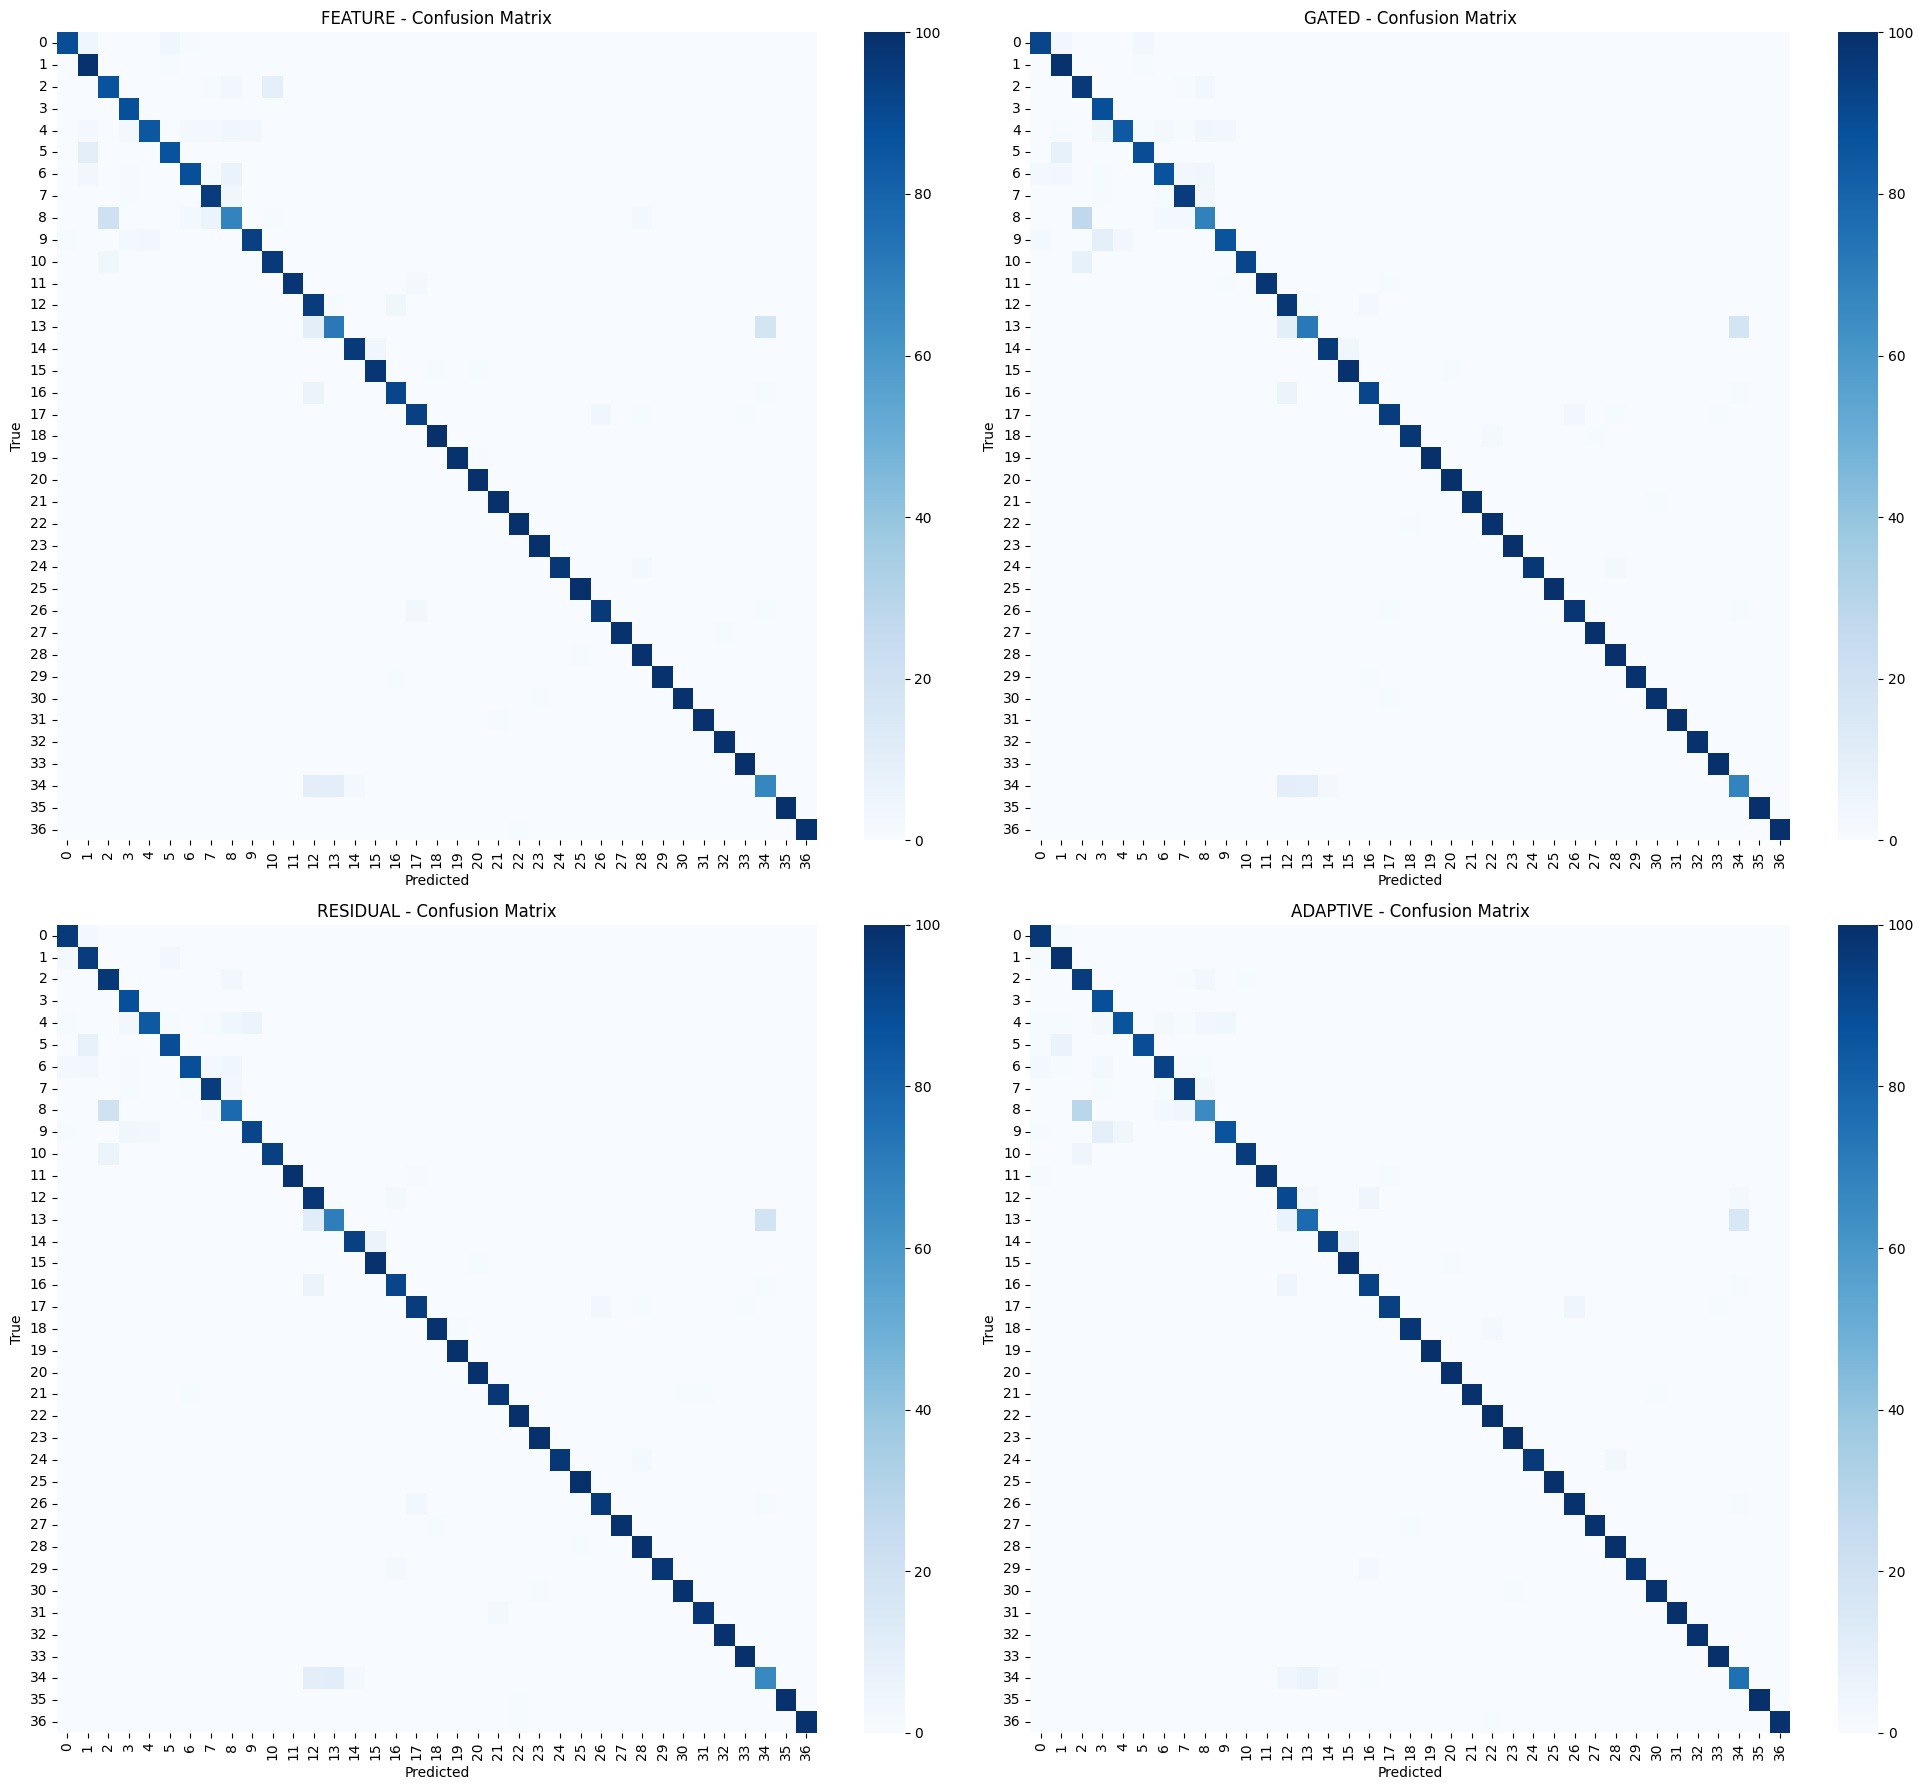


SAVING RESULTS
Results saved to: ./dpGCViT_Test_All_Results/results/fusion_comparison.csv
Detailed results saved to: ./dpGCViT_Test_All_Results/results/detailed_results.json
Report saved to: ./dpGCViT_Test_All_Results/results/classification_report_feature.txt
Report saved to: ./dpGCViT_Test_All_Results/results/classification_report_gated.txt
Report saved to: ./dpGCViT_Test_All_Results/results/classification_report_residual.txt
Report saved to: ./dpGCViT_Test_All_Results/results/classification_report_adaptive.txt

EVALUATION COMPLETE!

🏆 BEST METHOD: Adaptive
   Test Accuracy: 95.26%
   F1 Score:      0.9522
   Alpha Mean:    0.4496

Results saved to: ./dpGCViT_Test_All_Results


In [ ]:
# ==========================================================
# DP-GCViT MULTI-MODEL TEST SCRIPT (FIXED)
# ==========================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
from scipy.stats import entropy
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import timm
import json
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# PATHS & CONFIGURATION
# ==========================================================

class TestConfig:
    # Paths
    BASE_SAVE_DIR = "./dpGCViT_Test_All_Results"
    FIG_DIR = os.path.join(BASE_SAVE_DIR, "figures")
    MODEL_DIR = os.path.join(BASE_SAVE_DIR, "models")
    LOG_DIR = os.path.join(BASE_SAVE_DIR, "logs")
    RESULTS_DIR = os.path.join(BASE_SAVE_DIR, "results")

    # Data paths
    DATA_ROOT     = "/content/drive/MyDrive/The Oxford-IIIT Pet Dataset"
    IMAGES_DIR    = os.path.join(DATA_ROOT, "images", "images")
    ANNOT_DIR     = os.path.join(DATA_ROOT, "annotations", "annotations")

    TRAINVAL_FILE = os.path.join(ANNOT_DIR, "trainval.txt")
    TEST_FILE     = os.path.join(ANNOT_DIR, "test.txt")

    MODEL_PATH    = "/content/drive/MyDrive/dpGCViT_new_Results/models/best_model_adaptive.pth"

    # Model paths
    MODEL_PATHS = {
        'feature':  "/content/drive/MyDrive/dpGCViT_new_Results/models/best_model_feature.pth",
        'gated':    "/content/drive/MyDrive/dpGCViT_new_Results/models/best_model_gated.pth",
        'residual': "/content/drive/MyDrive/dpGCViT_new_Results/models/best_model_residual.pth",
        'adaptive': "/content/drive/MyDrive/dpGCViT_new_Results/models/best_model_adaptive.pth",
    }

    # Testing
    IMG_SIZE = 224
    BATCH_SIZE = 16
    NUM_WORKERS = 4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TTA = True

config = TestConfig()

# Create directories
os.makedirs(config.FIG_DIR, exist_ok=True)
os.makedirs(config.MODEL_DIR, exist_ok=True)
os.makedirs(config.LOG_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)

print(f"Using device: {config.DEVICE}")

# ==========================================================
# SEED FUNCTION
# ==========================================================

def set_seed(seed=44):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(44)

# ==========================================================
# CLASSES
# ==========================================================

ALL_CLASSES = sorted(list(set([line.strip().split()[0].rsplit("_", 1)[0]
                                for line in open(config.TRAINVAL_FILE)])))
class_to_idx = {c: i for i, c in enumerate(ALL_CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
num_classes = len(ALL_CLASSES)
print(f"Number of classes: {num_classes}")

# ==========================================================
# DATA TRANSFORMS
# ==========================================================

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(config.IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==========================================================
# DATASET
# ==========================================================

class OxfordPetDataset(Dataset):
    def __init__(self, list_file, img_dir, transform=None):
        self.transform = transform
        self.img_dir = img_dir
        self.samples = []
        with open(list_file) as f:
            for line in f:
                name = line.strip().split()[0]
                breed = name.rsplit("_", 1)[0]
                self.samples.append((name + ".jpg", class_to_idx[breed]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, label = self.samples[idx]
        image = Image.open(os.path.join(self.img_dir, img_name)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================================
# DATALOADER
# ==========================================================

test_dataset = OxfordPetDataset(config.TEST_FILE, config.IMAGES_DIR, eval_transform)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE,
                         shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)
print(f"Test samples: {len(test_dataset)}")

# ==========================================================
# MODEL DEFINITION
# ==========================================================

class DP_GCViT(nn.Module):
    def __init__(self, backbone, num_classes, init_alpha=0.5, fusion_mode='feature'):
        super().__init__()
        self.backbone = backbone
        self.num_features = backbone.num_features
        self.init_alpha = init_alpha
        self.fusion_mode = fusion_mode

        self.proj = nn.Sequential(
            nn.LayerNorm(self.num_features),
            nn.Linear(self.num_features, self.num_features),
            nn.GELU(),
            nn.Dropout(0.1)
        )

        self.part_fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.num_features, num_classes)
        )
        self.global_fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.num_features, num_classes)
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(self.num_features * 2, self.num_features // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(self.num_features // 2, 2),
        )

        self.fusion_fc = nn.Sequential(
            nn.Linear(self.num_features * 2, self.num_features),
            nn.LayerNorm(self.num_features),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(self.num_features, num_classes)
        )

        self.residual_proj = nn.Linear(self.num_features, self.num_features)
        self.confidence_proj = nn.Linear(num_classes, 1)
        self._init_fusion_gate()

    def _init_fusion_gate(self):
        with torch.no_grad():
            self.fusion_gate[-1].bias.data.fill_(0.0)
            for module in self.fusion_gate.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight, gain=0.5)
            for module in self.fusion_fc.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight, gain=0.5)
            nn.init.xavier_uniform_(self.residual_proj.weight, gain=0.5)
            nn.init.zeros_(self.residual_proj.bias)

    def forward(self, x, return_all=False):
        feat = self.backbone.forward_features(x)
        if feat.dim() == 4:
            feat = feat.flatten(2).transpose(1, 2)

        global_feat = feat.mean(dim=1)
        part_feat = feat.max(dim=1)[0]

        global_feat = self.proj(global_feat)
        part_feat = self.proj(part_feat)

        out_global = self.global_fc(global_feat)
        out_part = self.part_fc(part_feat)

        if self.fusion_mode == 'gated':
            gate_input = torch.cat([global_feat, part_feat], dim=1)
            fusion_weights = torch.softmax(self.fusion_gate(gate_input), dim=1)
            alpha = fusion_weights[:, 1:2]
            out_fused = fusion_weights[:, 0:1] * out_global + fusion_weights[:, 1:2] * out_part

        elif self.fusion_mode == 'feature':
            combined = torch.cat([global_feat, part_feat], dim=1)
            out_fused = self.fusion_fc(combined)
            gate_input = torch.cat([global_feat, part_feat], dim=1)
            alpha = torch.softmax(self.fusion_gate(gate_input), dim=1)[:, 1:2]

        elif self.fusion_mode == 'residual':
            residual = self.residual_proj(part_feat - global_feat)
            fused_feat = global_feat + 0.5 * residual
            out_fused = self.global_fc(fused_feat)
            gate_input = torch.cat([global_feat, part_feat], dim=1)
            alpha = torch.softmax(self.fusion_gate(gate_input), dim=1)[:, 1:2]

        elif self.fusion_mode == 'adaptive':
            probs_global = torch.softmax(out_global, dim=1)
            probs_part = torch.softmax(out_part, dim=1)
            conf_global, _ = torch.max(probs_global, dim=1, keepdim=True)
            conf_part, _ = torch.max(probs_part, dim=1, keepdim=True)
            total_conf = conf_global + conf_part + 1e-8
            weight_global = conf_global / total_conf
            weight_part = conf_part / total_conf
            out_fused = weight_global * out_global + weight_part * out_part
            alpha = weight_part.squeeze(-1)

        else:
            out_fused = (out_global + out_part) / 2
            alpha = torch.ones(out_global.size(0), 1, device=x.device) * 0.5
            alpha = alpha.squeeze(-1)

        if return_all:
            return out_fused, out_global, out_part, alpha.squeeze(-1) if alpha.dim() > 1 else alpha
        return out_fused


def load_model(model_path, fusion_mode, device):
    """Load trained model from checkpoint"""
    backbone = timm.create_model("gcvit_tiny", pretrained=False, num_classes=0)
    model = DP_GCViT(backbone, num_classes, init_alpha=0.5, fusion_mode=fusion_mode)

    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print(f"Loaded {fusion_mode} model from epoch {checkpoint.get('epoch', 0) + 1}")
    print(f"Best validation accuracy: {checkpoint.get('best_acc', 0):.2f}%")
    return model


# ==========================================================
# METRICS CALCULATOR
# ==========================================================

class MetricsCalculator:
    def __init__(self, num_classes, class_names):
        self.num_classes = num_classes
        self.class_names = class_names
        self.reset()

    def reset(self):
        self.y_true = []
        self.y_pred = []
        self.y_probs = []
        self.alphas = []
        self.losses = []

    def update(self, y_true, y_pred, y_probs, alpha=None, loss=None):
        self.y_true.extend(y_true)
        self.y_pred.extend(y_pred)
        self.y_probs.extend(y_probs)
        if alpha is not None:
            self.alphas.extend(alpha)
        if loss is not None:
            self.losses.append(loss)

    def compute_all_metrics(self):
        y_true = np.array(self.y_true)
        y_pred = np.array(self.y_pred)
        y_probs = np.array(self.y_probs)

        # Accuracy is returned as a DECIMAL (0.95), NOT percentage
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
        per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
        per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

        cm = confusion_matrix(y_true, y_pred)

        if self.num_classes > 2:
            y_true_bin = label_binarize(y_true, classes=range(self.num_classes))
            try:
                roc_auc = roc_auc_score(y_true_bin, y_probs, average='weighted', multi_class='ovr')
            except:
                roc_auc = 0.0
        else:
            try:
                roc_auc = roc_auc_score(y_true, y_probs[:, 1])
            except:
                roc_auc = 0.0

        max_probs = np.max(y_probs, axis=1)
        mean_confidence = np.mean(max_probs)
        confidence_std = np.std(max_probs)
        entropies = entropy(y_probs.T).mean() if y_probs.size > 0 else 0

        incorrect_indices = np.where(y_pred != y_true)[0]
        error_rate = len(incorrect_indices) / len(y_true) if len(y_true) > 0 else 0

        return {
            'accuracy': accuracy,                # DECIMAL: 0.95
            'accuracy_percent': accuracy * 100,  # PERCENTAGE: 95.28
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'mean_confidence': mean_confidence,
            'confidence_std': confidence_std,
            'entropy_mean': entropies,
            'error_rate': error_rate,
            'confusion_matrix': cm,
            'per_class_precision': per_class_precision,
            'per_class_recall': per_class_recall,
            'per_class_f1': per_class_f1,
            'num_errors': len(incorrect_indices),
            'total_samples': len(y_true)
        }

    def get_classification_report(self):
        y_true = np.array(self.y_true)
        y_pred = np.array(self.y_pred)
        return classification_report(y_true, y_pred, target_names=self.class_names, digits=3)


# ==========================================================
# TEST FUNCTION
# ==========================================================

def test_model(model, test_loader, device, tta=True):
    metrics_calc = MetricsCalculator(num_classes, ALL_CLASSES)
    model.eval()
    running_loss = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Testing", leave=False):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            if tta:
                out_fused1, out_global1, out_part1, alpha1 = model(x, return_all=True)
                x_flip = torch.flip(x, [3])
                out_fused2, out_global2, out_part2, alpha2 = model(x_flip, return_all=True)

                out_fused = (out_fused1 + out_fused2) / 2
                out_global = (out_global1 + out_global2) / 2
                out_part = (out_part1 + out_part2) / 2
                alpha = (alpha1 + alpha2) / 2
            else:
                out_fused, out_global, out_part, alpha = model(x, return_all=True)

            loss = criterion(out_fused, y)
            running_loss += loss.item()

            pred_fused = out_fused.argmax(1)
            probs_fused = torch.softmax(out_fused, dim=1)

            metrics_calc.update(
                y_true=y.cpu().numpy(),
                y_pred=pred_fused.cpu().numpy(),
                y_probs=probs_fused.cpu().numpy(),
                alpha=alpha.cpu().numpy().flatten(),
                loss=loss.item()
            )

    metrics = metrics_calc.compute_all_metrics()
    metrics['avg_loss'] = running_loss / len(test_loader)

    return metrics, metrics_calc


# ==========================================================
# PLOTTING FUNCTIONS
# ==========================================================

def plot_comparison(results_df, save_path):
    """Plot comparison of all fusion methods"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Convert accuracy to percentage for display
    results_df['Test Accuracy (%)'] = results_df['Test Accuracy'] * 100

    # 1. Accuracy Comparison (as percentage)
    axes[0, 0].bar(results_df['Method'], results_df['Test Accuracy (%)'],
                   color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    axes[0, 0].set_ylabel('Accuracy (%)')
    axes[0, 0].set_title('Test Accuracy Comparison')
    axes[0, 0].set_ylim(90, 100)
    for i, v in enumerate(results_df['Test Accuracy (%)']):
        axes[0, 0].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # 2. F1 Score Comparison
    axes[0, 1].bar(results_df['Method'], results_df['F1 Score'],
                   color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Score Comparison')
    axes[0, 1].set_ylim(0.90, 1.0)
    for i, v in enumerate(results_df['F1 Score']):
        axes[0, 1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # 3. Validation vs Test
    axes[0, 2].bar(results_df['Method'] + ' (Val)', results_df['Validation'],
                   alpha=0.7, label='Validation', color='blue')
    axes[0, 2].bar(results_df['Method'] + ' (Test)', results_df['Test Accuracy (%)'],
                   alpha=0.7, label='Test', color='green')
    axes[0, 2].set_ylabel('Accuracy (%)')
    axes[0, 2].set_title('Validation vs Test Accuracy')
    axes[0, 2].set_ylim(90, 100)
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    plt.setp(axes[0, 2].xaxis.get_majorticklabels(), rotation=45)

    # 4. Alpha Statistics
    axes[1, 0].bar(results_df['Method'], results_df['Alpha Mean'],
                   color='purple', alpha=0.7)
    axes[1, 0].axhline(y=0.5, color='red', linestyle='--', label='Balanced (0.5)')
    axes[1, 0].set_ylabel('Alpha Mean')
    axes[1, 0].set_title('Alpha Mean (Part Feature Weight)')
    axes[1, 0].set_ylim(0.2, 0.6)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(results_df['Alpha Mean']):
        axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

    # 5. Alpha Std
    axes[1, 1].bar(results_df['Method'], results_df['Alpha Std'],
                   color='orange', alpha=0.7)
    axes[1, 1].set_ylabel('Alpha Std')
    axes[1, 1].set_title('Alpha Standard Deviation')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(results_df['Alpha Std']):
        axes[1, 1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

    # 6. Improvement Summary (in percentage points)
    improvement = results_df['Test Accuracy (%)'] - results_df['Global Path']
    colors = ['green' if x > 0 else 'red' for x in improvement]
    axes[1, 2].bar(results_df['Method'], improvement, color=colors, alpha=0.7)
    axes[1, 2].axhline(y=0, color='black', linestyle='-')
    axes[1, 2].set_ylabel('Improvement over Global (%)')
    axes[1, 2].set_title('Improvement Summary')
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(improvement):
        axes[1, 2].text(i, v + 0.05 if v > 0 else v - 0.2, f'{v:.2f}%',
                        ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()


def plot_comparison_confusion_matrices(cm_dict, save_path):
    """Plot confusion matrices for all methods"""
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    methods = list(cm_dict.keys())

    for idx, (method, cm) in enumerate(cm_dict.items()):
        row = idx // 2
        col = idx % 2
        sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                    ax=axes[row, col], cbar=True)
        axes[row, col].set_title(f'{method.upper()} - Confusion Matrix')
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('True')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()


# ==========================================================
# MAIN EXECUTION
# ==========================================================

def main():
    print("\n" + "="*80)
    print("LOADING AND EVALUATING ALL FUSION MODELS")
    print("="*80)

    all_results = {}
    all_metrics_calc = {}
    all_confusion_matrices = {}

    # Loop through all fusion modes
    for fusion_mode, model_path in config.MODEL_PATHS.items():
        print("\n" + "="*60)
        print(f"EVALUATING {fusion_mode.upper()} MODEL")
        print("="*60)

        if not os.path.exists(model_path):
            print(f"⚠️ Model not found: {model_path}")
            continue

        model = load_model(model_path, fusion_mode, config.DEVICE)
        metrics, metrics_calc = test_model(model, test_loader, config.DEVICE, tta=config.TTA)

        all_results[fusion_mode] = metrics
        all_metrics_calc[fusion_mode] = metrics_calc
        all_confusion_matrices[fusion_mode] = metrics['confusion_matrix']

        # Print results
        print(f"\n--- {fusion_mode.upper()} RESULTS ---")
        print(f"Test Accuracy:  {metrics['accuracy'] * 100:.2f}%")
        print(f"F1 Score:       {metrics['f1_score']:.4f}")
        print(f"ROC AUC:        {metrics['roc_auc']:.4f}")
        print(f"Alpha Mean:     {np.mean(metrics_calc.alphas):.4f}")
        print(f"Alpha Std:      {np.std(metrics_calc.alphas):.4f}")
        print("-"*40)

    # Create comparison DataFrame
    data = []
    for method in all_results.keys():
        metrics = all_results[method]
        metrics_calc = all_metrics_calc[method]
        data.append({
            'Method': method.capitalize(),
            'Validation': 0,
            'Test Accuracy': metrics['accuracy'],  # Decimal
            'F1 Score': metrics['f1_score'],
            'ROC AUC': metrics['roc_auc'],
            'Global Path': 0,
            'Part Path': 0,
            'Alpha Mean': np.mean(metrics_calc.alphas),
            'Alpha Std': np.std(metrics_calc.alphas),
            'Mean Confidence': metrics['mean_confidence'],
            'Entropy': metrics['entropy_mean'],
            'Error Rate': metrics['error_rate']
        })

    results_df = pd.DataFrame(data)

    # Add validation and path accuracies from logs
    val_acc    = {'feature': 96.74, 'gated': 97.15, 'residual': 96.74, 'adaptive': 96.88}
    global_acc = {'feature': 94.41, 'gated': 94.63, 'residual': 95.01, 'adaptive': 94.96}
    part_acc   = {'feature': 94.55, 'gated': 94.44, 'residual': 94.90, 'adaptive': 94.93}

    for method in results_df['Method']:
        key = method.lower()
        results_df.loc[results_df['Method'] == method, 'Validation']  = val_acc.get(key, 0)
        results_df.loc[results_df['Method'] == method, 'Global Path'] = global_acc.get(key, 0)
        results_df.loc[results_df['Method'] == method, 'Part Path']   = part_acc.get(key, 0)

    # Print comparison table
    print("\n" + "="*80)
    print("COMPARISON SUMMARY")
    print("="*80)

    display_df = results_df.copy()
    display_df['Test Accuracy'] = (display_df['Test Accuracy'] * 100).round(2)
    display_df['Validation']    = display_df['Validation'].round(2)
    display_df['Global Path']   = display_df['Global Path'].round(2)
    display_df['Part Path']     = display_df['Part Path'].round(2)
    display_df['F1 Score']      = display_df['F1 Score'].round(4)
    display_df['Alpha Mean']    = display_df['Alpha Mean'].round(4)
    display_df['Alpha Std']     = display_df['Alpha Std'].round(4)

    print(display_df[['Method', 'Validation', 'Test Accuracy', 'F1 Score',
                       'Global Path', 'Part Path', 'Alpha Mean', 'Alpha Std']].to_string(index=False))

    # ==========================================================
    # PLOTTING
    # ==========================================================

    print("\n" + "="*60)
    print("GENERATING COMPARISON PLOTS")
    print("="*60)

    plot_comparison(
        results_df,
        os.path.join(config.FIG_DIR, "fusion_comparison.png")
    )
    plot_comparison_confusion_matrices(
        all_confusion_matrices,
        os.path.join(config.FIG_DIR, "all_confusion_matrices.png")
    )

    # ==========================================================
    # SAVE RESULTS
    # ==========================================================

    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)

    results_df.to_csv(os.path.join(config.RESULTS_DIR, "fusion_comparison.csv"), index=False)
    print(f"Results saved to: {os.path.join(config.RESULTS_DIR, 'fusion_comparison.csv')}")

    detailed_results = {}
    for method in all_results.keys():
        metrics = all_results[method]
        metrics_calc = all_metrics_calc[method]
        detailed_results[method] = {
            'test_accuracy_percent':  float(metrics['accuracy'] * 100),
            'test_accuracy_decimal':  float(metrics['accuracy']),
            'f1_score':               float(metrics['f1_score']),
            'precision':              float(metrics['precision']),
            'recall':                 float(metrics['recall']),
            'roc_auc':                float(metrics['roc_auc']),
            'mean_confidence':        float(metrics['mean_confidence']),
            'error_rate':             float(metrics['error_rate']),
            'alpha_mean':             float(np.mean(metrics_calc.alphas)),
            'alpha_std':              float(np.std(metrics_calc.alphas))
        }

    with open(os.path.join(config.RESULTS_DIR, "detailed_results.json"), 'w') as f:
        json.dump(detailed_results, f, indent=4)
    print(f"Detailed results saved to: {os.path.join(config.RESULTS_DIR, 'detailed_results.json')}")

    # ==========================================================
    # CLASSIFICATION REPORTS
    # ==========================================================

    for method in all_metrics_calc.keys():
        report_path = os.path.join(config.RESULTS_DIR, f"classification_report_{method}.txt")
        with open(report_path, 'w') as f:
            f.write(f"Classification Report - {method.upper()}\n")
            f.write("="*60 + "\n")
            f.write(all_metrics_calc[method].get_classification_report())
        print(f"Report saved to: {report_path}")

    # ==========================================================
    # FINAL SUMMARY
    # ==========================================================

    print("\n" + "="*80)
    print("EVALUATION COMPLETE!")
    print("="*80)

    # Find best method
    best_idx = results_df['Test Accuracy'].idxmax()
    best_method = results_df.loc[best_idx]

    print(f"\n🏆 BEST METHOD: {best_method['Method']}")
    print(f"   Test Accuracy: {best_method['Test Accuracy'] * 100:.2f}%")
    print(f"   F1 Score:      {best_method['F1 Score']:.4f}")
    print(f"   Alpha Mean:    {best_method['Alpha Mean']:.4f}")

    print(f"\nResults saved to: {config.BASE_SAVE_DIR}")
    print("="*80)


if __name__ == '__main__':
    main()

In [ ]:
# ==========================================================
# PRINT CLASSIFICATION REPORT FOR ADAPTIVE FUSION
# ==========================================================

# Load adaptive model
model = load_model(
    config.MODEL_PATHS["adaptive"],
    "adaptive",
    config.DEVICE
)

# Evaluate on the test set
metrics, metrics_calc = test_model(
    model,
    test_loader,
    config.DEVICE,
    tta=config.TTA
)

# Print classification report
print("\n" + "=" * 80)
print("ADAPTIVE FUSION CLASSIFICATION REPORT")
print("=" * 80)
print(metrics_calc.get_classification_report())

Loaded adaptive model from epoch 5
Best validation accuracy: 96.88%



ADAPTIVE FUSION CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                Abyssinian      0.933     0.990     0.960        98
                    Bengal      0.908     0.990     0.947       100
                    Birman      0.736     0.950     0.830       100
                    Bombay      0.863     1.000     0.926        88
         British_Shorthair      0.956     0.860     0.905       100
              Egyptian_Mau      1.000     0.918     0.957        97
                Maine_Coon      0.949     0.930     0.939       100
                   Persian      0.931     0.950     0.941       100
                   Ragdoll      0.867     0.650     0.743       100
              Russian_Blue      0.956     0.860     0.905       100
                   Siamese      0.990     0.950     0.969       100
                    Sphynx      1.000     0.980     0.990       100
          american_bulldog      0.850     0.910     0.879       100
 america